# Notebook 1 — Symmetries and Group Actions in Data

**Module 1, Section 1.1 — Geometric Learning**

This notebook accompanies Section 1.1. We will:

1. Implement group elements ($\mathrm{SO}(2)$, $S_n$) as concrete Python objects and verify the group axioms numerically.
2. Visualise the *orbit* of a point under a group action.
3. Witness the **striking example**: an MLP trained on upright digits collapses to chance-level accuracy on rotated digits. Training on **the orbit** (rotation-augmented data) — same architecture, same training time — restores accuracy across all angles. The improvement comes purely from injecting symmetry as inductive bias.

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from scipy.ndimage import rotate

np.random.seed(0)
plt.rcParams['figure.dpi'] = 110

## 1. Groups as Python objects

### $\mathrm{SO}(2)$ — rotations of the plane

In [2]:
def R(theta):
    c, s = np.cos(theta), np.sin(theta)
    return np.array([[c, -s], [s, c]])

a, b = 0.7, 1.3
assert np.allclose(R(a) @ R(b), R(a + b)), 'closure / homomorphism'
assert np.allclose(R(0), np.eye(2)),       'identity'
assert np.allclose(R(a) @ R(-a), np.eye(2)),'inverse'
print('SO(2) group axioms verified numerically.')

SO(2) group axioms verified numerically.


### Visualising an orbit

The **orbit** of $x \in \mathbb{R}^2$ under $\mathrm{SO}(2)$ is the circle of radius $\|x\|$.

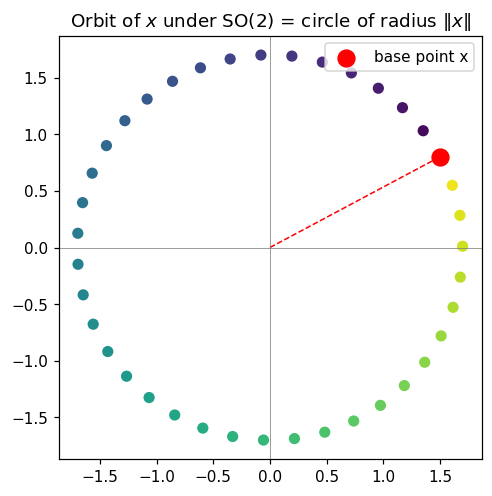

In [3]:
x = np.array([1.5, 0.8])
thetas = np.linspace(0, 2*np.pi, 40)
orbit = np.array([R(t) @ x for t in thetas])

fig, ax = plt.subplots(figsize=(5,5))
ax.scatter(orbit[:,0], orbit[:,1], c=thetas, cmap='viridis', s=40)
ax.scatter(*x, c='red', s=120, zorder=5, label='base point x')
ax.plot([0, x[0]], [0, x[1]], 'r--', lw=1)
ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)
ax.set_aspect('equal'); ax.legend()
ax.set_title(r'Orbit of $x$ under $\mathrm{SO}(2)$ = circle of radius $\|x\|$')
plt.show()

### Permutation group $S_n$ acting on graphs

$\sigma \cdot A = P_\sigma A P_\sigma^\top$ — the same graph, relabelled.

In [4]:
A = np.array([[0,1,0,1],
              [1,0,1,0],
              [0,1,0,1],
              [1,0,1,0]])

sigma = np.array([2, 0, 3, 1])
P = np.eye(4)[sigma]
A_perm = P @ A @ P.T

print('Original adjacency:')
print(A)
print()
print('Permuted adjacency:')
print(A_perm.astype(int))
print()
print('Same graph up to relabelling -- both lie in the same orbit.')

Original adjacency:
[[0 1 0 1]
 [1 0 1 0]
 [0 1 0 1]
 [1 0 1 0]]

Permuted adjacency:
[[0 0 1 1]
 [0 0 1 1]
 [1 1 0 0]
 [1 1 0 0]]

Same graph up to relabelling -- both lie in the same orbit.


In [5]:
# How big is the orbit of A under S_4 ?
from itertools import permutations
orbit_mats = set()
for perm in permutations(range(4)):
    Pp = np.eye(4)[list(perm)]
    M = (Pp @ A @ Pp.T).astype(int)
    orbit_mats.add(M.tobytes())

print(f'|S_4| = 24,  but the orbit has only {len(orbit_mats)} distinct adjacency matrices.')
print(f'Stabiliser size = 24 / {len(orbit_mats)} = {24 // len(orbit_mats)}')
print('(The graph has internal symmetries that fix it.)')

|S_4| = 24,  but the orbit has only 3 distinct adjacency matrices.
Stabiliser size = 24 / 3 = 8
(The graph has internal symmetries that fix it.)


## 2. Striking example — symmetry as inductive bias

We train two identical MLPs (same architecture, same epochs) on handwritten digits:

- **Plain MLP** — trained only on upright digits.
- **Orbit-trained MLP** — at training time, each digit is presented in 8 rotated versions (its full orbit under $C_8$). The model sees no new images, only orbit-augmented copies of the training set.

We evaluate both on rotated test digits.

In [6]:
digits = load_digits()
X, y = digits.data, digits.target
X_img = X.reshape(-1, 8, 8)

X_train, X_test, y_train, y_test = train_test_split(
    X_img, y, test_size=0.3, random_state=0)

def rotate_batch(X, angle):
    return np.array([rotate(im, angle, reshape=False, order=1) for im in X])

# --- Plain MLP (no symmetry) ----------------------------------------------
clf_plain = MLPClassifier(hidden_layer_sizes=(64,), max_iter=200, random_state=0)
clf_plain.fit(X_train.reshape(-1, 64), y_train)

# --- Orbit-trained MLP (C_8-symmetric augmentation) -----------------------
rot_angles_train = [0, 45, 90, 135, 180, 225, 270, 315]
X_aug = np.concatenate([rotate_batch(X_train, a) for a in rot_angles_train])
y_aug = np.concatenate([y_train] * len(rot_angles_train))

clf_orbit = MLPClassifier(hidden_layer_sizes=(64,), max_iter=200, random_state=0)
clf_orbit.fit(X_aug.reshape(-1, 64), y_aug)

print('Training-set sizes:')
print(f'  plain : {X_train.shape[0]:>6}')
print(f'  orbit : {X_aug.shape[0]:>6}  ({len(rot_angles_train)}x)')

Training-set sizes:
  plain :   1257
  orbit :  10056  (8x)


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


In [7]:
angles = [0, 15, 30, 45, 60, 90, 135, 180]

plain_acc, orbit_acc = [], []
for a in angles:
    Xa = rotate_batch(X_test, a).reshape(-1, 64)
    plain_acc.append(clf_plain.score(Xa, y_test))
    orbit_acc.append(clf_orbit.score(Xa, y_test))
    print(f'   angle {a:>3} deg  ->  plain = {plain_acc[-1]:.3f}    orbit = {orbit_acc[-1]:.3f}')

   angle   0 deg  ->  plain = 0.969    orbit = 0.922
   angle  15 deg  ->  plain = 0.652    orbit = 0.407
   angle  30 deg  ->  plain = 0.285    orbit = 0.633
   angle  45 deg  ->  plain = 0.119    orbit = 0.943
   angle  60 deg  ->  plain = 0.093    orbit = 0.483
   angle  90 deg  ->  plain = 0.089    orbit = 0.948
   angle 135 deg  ->  plain = 0.089    orbit = 0.928
   angle 180 deg  ->  plain = 0.335    orbit = 0.935


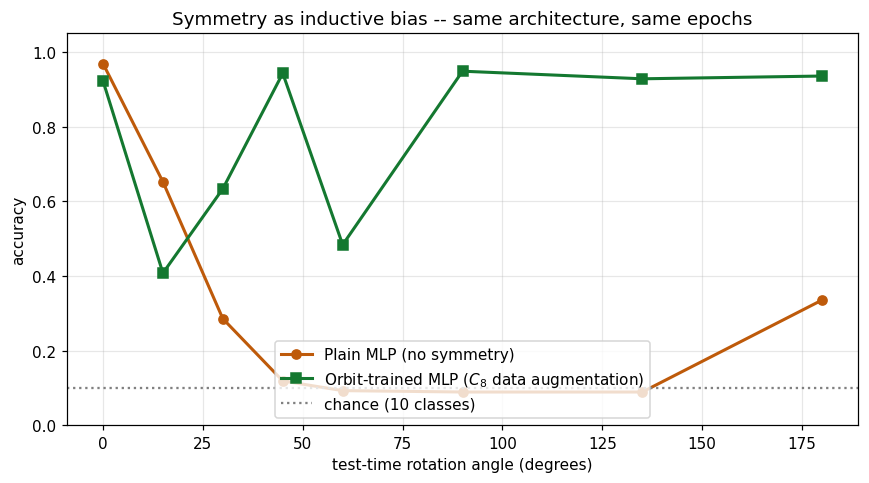

In [8]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(angles, plain_acc, 'o-', color='#BE5A0A', lw=2,
        label='Plain MLP (no symmetry)')
ax.plot(angles, orbit_acc, 's-', color='#147830', lw=2,
        label=r'Orbit-trained MLP ($C_8$ data augmentation)')
ax.axhline(0.10, color='gray', ls=':', label='chance (10 classes)')
ax.set_xlabel('test-time rotation angle (degrees)')
ax.set_ylabel('accuracy')
ax.set_title('Symmetry as inductive bias -- same architecture, same epochs')
ax.set_ylim(0, 1.05); ax.legend(loc='lower center'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

**Reading the plot.** Same architecture, same training time. The orange MLP has never seen a rotated digit and collapses to chance for any large rotation. The green MLP, trained on $C_8$ orbits of the same images, generalises across the *entire* circle of rotations — including angles ($15°, 30°, 60°$, ...) it was never explicitly trained on. The orbits act as a $C_8$-invariant *prior*, and interpolation between training rotations does the rest.

This is the cleanest possible illustration of the message of Section 1.1:

> *Symmetry $\Leftrightarrow$ inductive bias $\Leftrightarrow$ better generalisation.*

Notice an important subtlety: **orbit-augmentation gives the network a soft invariance** (only approximately, since the network is not architecturally $C_8$-equivariant). A truly $G$-equivariant *architecture* (e.g.\ group-convolutional networks, $G$-CNNs) would achieve the same robustness with $|G|$-fewer training images — that is the lesson of Section 1.2.

### Visualising the rotated test digits

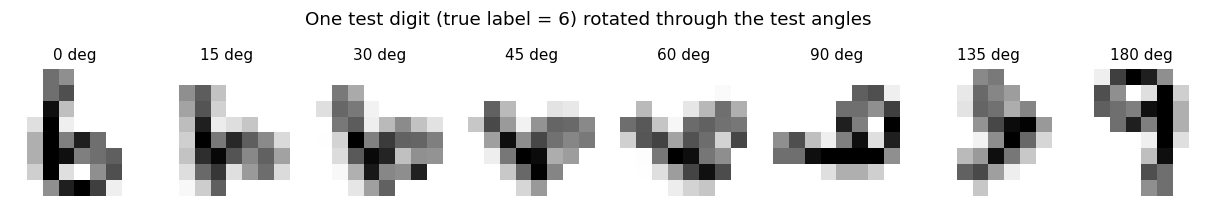

In [9]:
sample = X_test[3]
fig, axes = plt.subplots(1, len(angles), figsize=(14, 2))
for ax, a in zip(axes, angles):
    ax.imshow(rotate(sample, a, reshape=False, order=1), cmap='gray_r')
    ax.set_title(f'{a} deg', fontsize=10); ax.axis('off')
plt.suptitle(f'One test digit (true label = {y_test[3]}) rotated through the test angles',
             y=1.05)
plt.show()

## Exercises (open-ended)

1. Change the augmentation group from $C_8$ to $C_4$ and to $C_{16}$. Plot test accuracy at $22.5°$ as a function of $|G|$. Why does it plateau?
2. The orbit-trained model used **8x more training data**. Is there a fair comparison where the plain MLP gets 8x more training *epochs* instead? Re-run and discuss.
3. Build the orbit of the 4-cycle graph $A$ (above) under $S_4$ by enumerating all $4! = 24$ permutations. Verify that the orbit has size $24 / |\mathrm{Stab}(A)|$ — and find the stabiliser explicitly.